# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 27
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,2b0d03f,1.059162,26.4,KEEP,baseline
1,fc4dcc8,1.060413,26.4,DISCARD,shorten LR warmdown to last quarter
2,9b7acfc,1.048669,33.9,KEEP,increase width from 384 to 512
3,a1f644c,1.045843,39.0,KEEP,add one more 512d layer
4,6b66308,1.048791,39.0,DISCARD,use full attention windows
5,acf31a9,1.050510,43.8,DISCARD,add an eighth 512d layer
6,154b430,1.044496,39.0,KEEP,add 5 percent warmup
7,6dcba6e,1.047385,39.0,DISCARD,increase warmup to 10 percent
8,eff7f41,1.044096,39.0,KEEP,keep 10 percent final LR
9,ade3ad7,1.045507,39.0,DISCARD,keep 20 percent final LR


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    14
KEEP       13

Keep rate: 13/27 = 48.1%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (13 total):

  #  0  bpb=1.059162  mem=26.4GB  baseline
  #  2  bpb=1.048669  mem=33.9GB  increase width from 384 to 512
  #  3  bpb=1.045843  mem=39.0GB  add one more 512d layer
  #  6  bpb=1.044496  mem=39.0GB  add 5 percent warmup
  #  8  bpb=1.044096  mem=39.0GB  keep 10 percent final LR
  # 14  bpb=1.043840  mem=39.0GB  use short windows in all intermediate layers
  # 15  bpb=1.039225  mem=39.0GB  reduce short attention window to quarter context
  # 16  bpb=1.036225  mem=39.0GB  reduce short attention window to eighth context
  # 18  bpb=1.036115  mem=39.0GB  raise Muon matrix LR slightly on 1/8 context
  # 20  bpb=1.031060  mem=19.7GB  try smaller total batch with 64 device batch
  # 22  bpb=1.030021  mem=19.7GB  lower final LR fraction on small batch setup
  # 24  bpb=1.029867  mem=19.7GB  start warmdown earlier on small batch setup
  # 25  bpb=1.029759  mem=19.7GB  start warmdown even earlier on small batch setup


## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

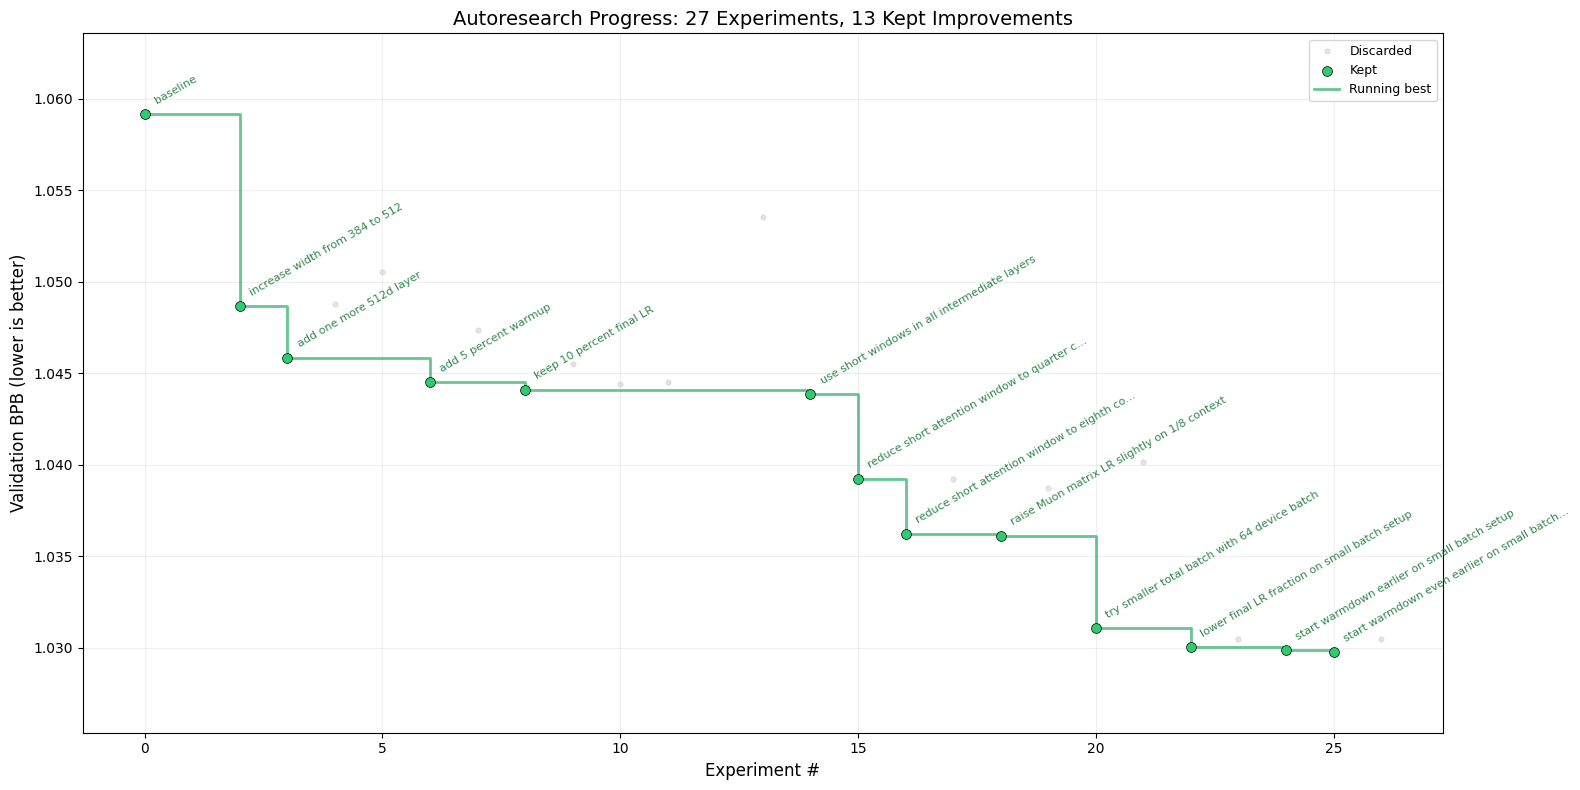

Saved to progress.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best_bpb = kept_bpb.min()
margin = (baseline_bpb - best_bpb) * 0.15
ax.set_ylim(best_bpb - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  1.059162
Best val_bpb:      1.029759
Total improvement: 0.029403 (2.78%)
Best experiment:   start warmdown even earlier on small batch setup

Cumulative effort per improvement:
  Experiment #  0: bpb=1.059162  baseline
  Experiment #  2: bpb=1.048669  increase width from 384 to 512
  Experiment #  3: bpb=1.045843  add one more 512d layer
  Experiment #  6: bpb=1.044496  add 5 percent warmup
  Experiment #  8: bpb=1.044096  keep 10 percent final LR
  Experiment # 14: bpb=1.043840  use short windows in all intermediate layers
  Experiment # 15: bpb=1.039225  reduce short attention window to quarter context
  Experiment # 16: bpb=1.036225  reduce short attention window to eighth context
  Experiment # 18: bpb=1.036115  raise Muon matrix LR slightly on 1/8 context
  Experiment # 20: bpb=1.031060  try smaller total batch with 64 device batch
  Experiment # 22: bpb=1.030021  lower final LR fraction on small batch setup
  Experiment # 24: bpb=1.029867  start warmdown earlie

## Top Hits (Kept Experiments by Improvement)

In [6]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.010493  1.048669  increase width from 384 to 512
   2  +0.005055  1.031060  try smaller total batch with 64 device batch
   3  +0.004615  1.039225  reduce short attention window to quarter context
   4  +0.003000  1.036225  reduce short attention window to eighth context
   5  +0.002826  1.045843  add one more 512d layer
   6  +0.001347  1.044496  add 5 percent warmup
   7  +0.001039  1.030021  lower final LR fraction on small batch setup
   8  +0.000400  1.044096  keep 10 percent final LR
   9  +0.000256  1.043840  use short windows in all intermediate layers
  10  +0.000154  1.029867  start warmdown earlier on small batch setup
  11  +0.000110  1.036115  raise Muon matrix LR slightly on 1/8 context
  12  +0.000108  1.029759  start warmdown even earlier on small batch setup

      +0.029403              TOTAL improvement over baseline
